## Modify this section  

In [18]:
from functions_EMG_2025 import *    # modify the .py file name

EMG_file = "train1_data.csv" #training dataset
EMG2_file = "test1_data.csv" #testing dataset
label_file = "train1_labels.csv"
label2_file = "test1_labels.csv"

## Do not modify this section

### Test 1 

debut acquisition
frequence acquisition : 536068.1 sps


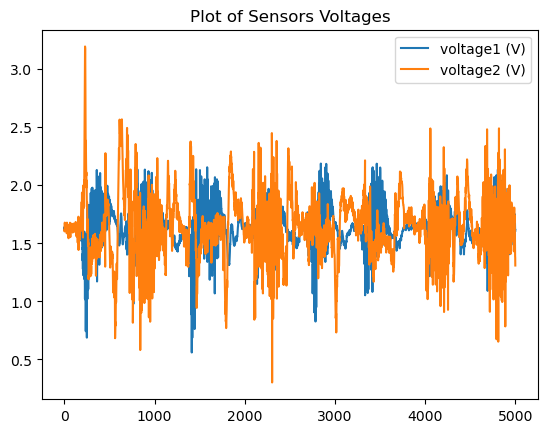

Démarrage classification temps réel...
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
P

In [19]:
@dataclass
class OfflineStream:

    def __init__(self, data):
        self.data = data            # array of emg data read from csv file
        self.pointer = 0            # pointer to the current emg data in the array

    @property
    def voltage(self):
        if self.pointer < len(self.data):
            value = self.data[self.pointer]
            self.pointer += 1
        else:
            value = 0.0
        return value


@dataclass
class OutputSim:

    def __init__(self):
        self.logs = [0]

    def ChangeFrequency(self, freq):
        if freq == 325:
            self.logs.append(1)
        else:
            self.logs.append(2)

    def ChangeDutyCycle(self, freq):
        if freq == 30:
            self.logs.append(1)
        else:
            self.logs.append(2)

    def start(self, value):
        pass

    def stop(self):
        self.logs.append(0)

Y = pd.read_csv(label_file)

chan1 = OfflineStream(pd.read_csv(EMG_file).values[:, 0])       # chan 1 emulator
chan2 = OfflineStream(pd.read_csv(EMG_file).values[:, 1])       # chan 2 emulator
chan3 = OfflineStream(pd.read_csv(EMG2_file).values[:, 0])       # chan 1 emulator
chan4 = OfflineStream(pd.read_csv(EMG2_file).values[:, 1])       # chan 2 emulator
buzzer = OutputSim()                                            # buzzer emulator

# general parameters
window_size = 50                                                # evaluation window length (samples)
number_window_training = 100                                     # number of windows to sample for training data set
number_window_testing = 100                                      # number of windows to sample for offline testing

training_file_name = create_new_sampling_file("data/", "training_acquisition")
acquire_training_dataset(chan1, chan2, window_size, number_window_training, training_file_name)

# visual validation of data acquisition
visualize_sampling(training_file_name)

# classifier training (offline training)
classifier = train_classifier(training_file_name, window_size)

# buzzer control (online test)
testing_file_name = create_new_sampling_file("data/", "testing_acquisition")
final_labels = test_classifier(classifier, chan3, chan4, window_size, number_window_testing,buzzer, testing_file_name)

print(final_labels)

del chan1
del chan2
del buzzer


Mean class accuracy: 0.8373015873015873
Confusion Matrix:
 [[1.         0.         0.        ]
 [0.32142857 0.67857143 0.        ]
 [0.16666667 0.         0.83333333]]


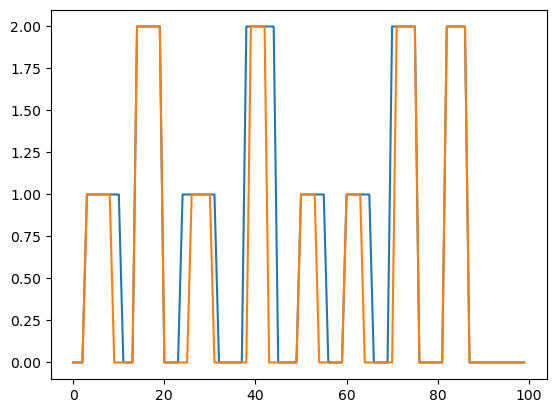

In [20]:
# Performance analysis

LT = pd.read_csv(label2_file)
labels = LT['Downsampled Carrier']

switched_labels=final_labels

from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# Calculate the mean class accuracy
mean_class_accuracy1 = balanced_accuracy_score(labels, switched_labels)

# Create the confusion matrix
conf_matrix1 = confusion_matrix(labels, switched_labels, normalize='true')

print("Mean class accuracy:", mean_class_accuracy1)
print("Confusion Matrix:\n", conf_matrix1)

plt.plot(labels)
plt.plot(switched_labels)

### Test 2 

In [21]:
EMG_file = "test1_data.csv"
EMG2_file = "train1_data.csv"
label_file = "test1_labels.csv"
label2_file = "train1_labels.csv"

debut acquisition
frequence acquisition : 532758.87 sps


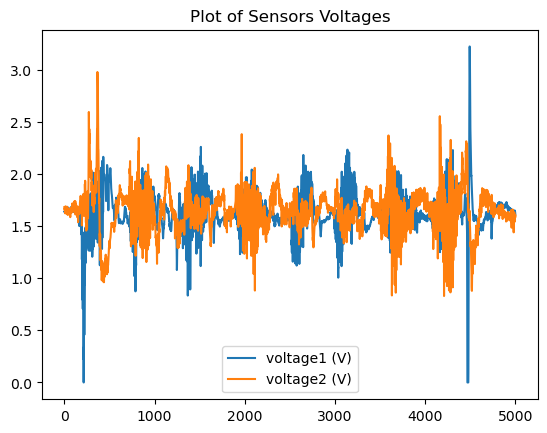

Démarrage classification temps réel...
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 2
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 1
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
Prediction : 0
P

In [22]:
@dataclass
class OfflineStream:

    def __init__(self, data):
        self.data = data            # array of emg data read from csv file
        self.pointer = 0            # pointer to the current emg data in the array

    @property
    def voltage(self):
        if self.pointer < len(self.data):
            value = self.data[self.pointer]
            self.pointer += 1
        else:
            value = 0.0
        return value


@dataclass
class OutputSim:

    def __init__(self):
        self.logs = [0]

    def ChangeFrequency(self, freq):
        if freq == 325:
            self.logs.append(1)
        else:
            self.logs.append(2)

    def ChangeDutyCycle(self, freq):
        if freq == 30:
            self.logs.append(1)
        else:
            self.logs.append(2)

    def start(self, value):
        pass

    def stop(self):
        self.logs.append(0)

Y = pd.read_csv(label_file)

chan1 = OfflineStream(pd.read_csv(EMG_file).values[:, 0])       # chan 1 emulator
chan2 = OfflineStream(pd.read_csv(EMG_file).values[:, 1])       # chan 2 emulator
chan3 = OfflineStream(pd.read_csv(EMG2_file).values[:, 0])       # chan 1 emulator
chan4 = OfflineStream(pd.read_csv(EMG2_file).values[:, 1])       # chan 2 emulator
buzzer = OutputSim()                                            # buzzer emulator

# general parameters
window_size = 50                                                # evaluation window length (samples)
number_window_training = 100                                     # number of windows to sample for training data set
number_window_testing = 100                                      # number of windows to sample for offline testing

training_file_name = create_new_sampling_file("data/", "training_acquisition")
acquire_training_dataset(chan1, chan2, window_size, number_window_training, training_file_name)

# visual validation of data acquisition
visualize_sampling(training_file_name)

# classifier training (offline training)
classifier = train_classifier(training_file_name, window_size)

# buzzer control (online test)
testing_file_name = create_new_sampling_file("data/", "testing_acquisition")
final_labels = test_classifier(classifier, chan3, chan4, window_size, number_window_testing,buzzer, testing_file_name)

print(final_labels)

del chan1
del chan2
del buzzer

Mean class accuracy: 0.8349875930521092
Confusion Matrix:
 [[1.         0.         0.        ]
 [0.26923077 0.73076923 0.        ]
 [0.22580645 0.         0.77419355]]


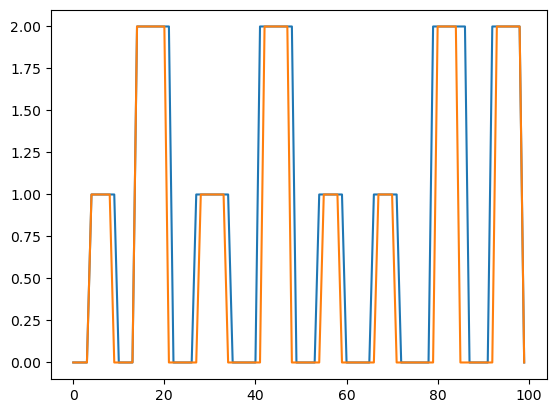

In [23]:
# Performance analysis

LT = pd.read_csv(label2_file)
labels = LT['Downsampled Carrier']

switched_labels=final_labels

from sklearn.metrics import confusion_matrix, balanced_accuracy_score

# Calculate the mean class accuracy
mean_class_accuracy2 = balanced_accuracy_score(labels, switched_labels)

# Create the confusion matrix
conf_matrix2 = confusion_matrix(labels, switched_labels, normalize='true')

print("Mean class accuracy:", mean_class_accuracy2)
print("Confusion Matrix:\n", conf_matrix2)

plt.plot(labels)
plt.plot(switched_labels)

### Result of the performance analysis

In [24]:
print("Mean class accuracy test 1:", mean_class_accuracy1)
print("Mean class accuracy test 2:", mean_class_accuracy2)
print ("Mean class accuracy:",(mean_class_accuracy1+mean_class_accuracy2)/2)

Mean class accuracy test 1: 0.8373015873015873
Mean class accuracy test 2: 0.8349875930521092
Mean class accuracy: 0.8361445901768483
